# Compare NetCDF Coordinates

This notebook reads two NetCDF files and checks if their latitude and longitude coordinate arrays are the same.

## 1. Import Required Libraries

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import uxarray as ux

import warnings
warnings.filterwarnings("ignore")


## 2. Load NetCDF File

Specify the paths to your two NetCDF files and load them.

In [2]:
# --- CONFIGURATION ---
icase="scream_cpu_dpxx_RCE_dx1km"
indir = f"/pscratch/sd/k/ksa/simulation/DP-SCREAM/cases/{icase}/run"
dpscream_file = f"{icase}.hist.INSTANT.nmins_x5.2000-01-01-00000.nc"
#grid_file = "/global/cfs/cdirs/wcm_shr/DP-SCREAM/remap/scrip_DPSCREAM_RCE_dx5km_500x500km.nc"
grid_file = "/global/cfs/cdirs/wcm_shr/DP-SCREAM/remap/scrip_DPSCREAM_RCE_dx1km_600x600km.nc"



In [3]:

# --- LOAD DATA ---
uxds = ux.open_dataset(grid_file, (indir + "/" + dpscream_file))


### vertical coordinate


In [4]:
zmid = uxds['z_mid']

In [5]:
zmid_havg = zmid.mean(dim='n_face')

In [6]:
zmid_avg = zmid.mean(dim=['n_face', 'time'])

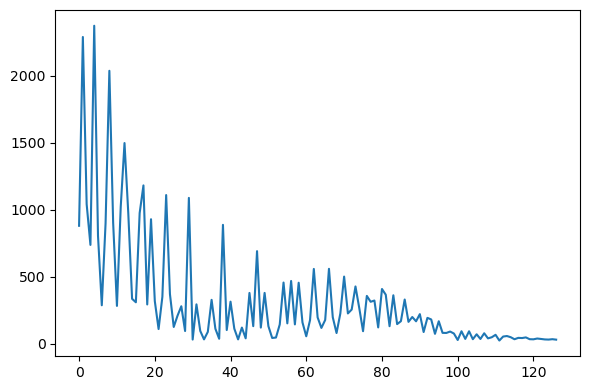

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))

_=ax.plot(np.diff(zmid_avg)*-1)


plt.tight_layout()
plt.show()

fig.clear() #this does free memory: https://stackoverflow.com/a/55834853/20647995
plt.close(fig)

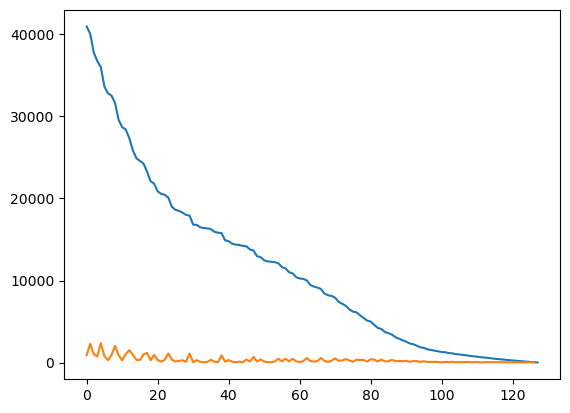

In [31]:
plt.plot(zmid_avg)


plt.plot(np.diff(zmid_avg)*-1)

In [5]:
# 1. Extract Arrays
invarname = "z_mid"
intime = 11
ilev=None

if ilev is not None:
    invar = uxds[invarname].isel(time=intime, lev=ilev)
else:
    invar = uxds[invarname].isel(time=intime)



In [6]:
invar

<xarray.UxDataArray 'z_mid' (n_face: 160000, lev: 128)> Size: 82MB
[20480000 values with dtype=float32]
Coordinates:
  * lev      (lev) float32 512B 2.58 3.23 3.88 4.597 ... 987.2 991.0 994.9 998.5
    time     object 8B 2000-01-01 00:55:00
Dimensions without coordinates: n_face
Attributes:
    units:      m
    long_name:  elevation above sealevel at level midpoints

In [13]:
iplot = invar.isel(n_face=0)
iplot.max()
iplot.min()

<xarray.UxDataArray 'z_mid' ()> Size: 8B
array(40989.0859375)
Coordinates:
    time     object 8B 2000-01-01 00:55:00

<xarray.UxDataArray 'z_mid' ()> Size: 8B
array(13.23694229)
Coordinates:
    time     object 8B 2000-01-01 00:55:00

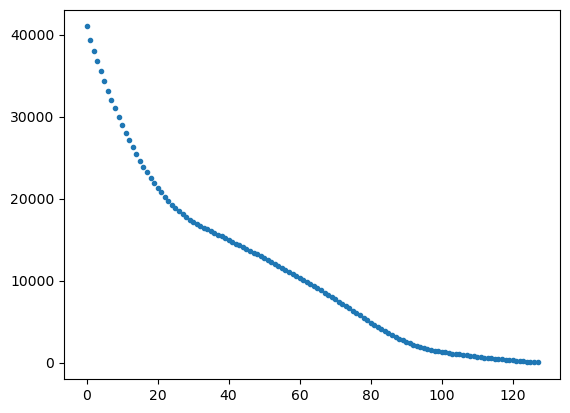

In [12]:
plt.plot(iplot.T,'.')


In [18]:
iplot.isel(lev=slice(-5, None))

<xarray.UxDataArray 'z_mid' (n_face: 1, lev: 5)> Size: 20B
array([[146.29596 , 112.74612 ,  79.6536  ,  44.650745,  13.236942]],
      dtype=float32)
Coordinates:
  * lev      (lev) float32 20B 983.5 987.2 991.0 994.9 998.5
    time     object 8B 2000-01-01 00:55:00
Dimensions without coordinates: n_face
Attributes:
    units:      m
    long_name:  elevation above sealevel at level midpoints

In [ ]:

cmin = None
cmax = None


In [ ]:
# Create figure and axis
#fig, ax = plt.subplots(figsize=(10, 8))

# Plot on the specified axis
invar.isel(lev=ilev).plot(backend='matplotlib', cmap='jet', aspect=1, clim=(cmin,cmax))



# plt.tight_layout()
# plt.show()

In [ ]:
invar